In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
df1 = pd.read_csv('../data/raw/Chicago_Crimes_2012_to_2017.csv', 
                  low_memory=False)

df = pd.concat([df1], ignore_index=True)
print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Total records: 1,456,714
Columns: ['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


In [5]:
print(df.shape)
print("\nNull values per column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

(1456714, 23)

Null values per column:
Unnamed: 0                  0
ID                          0
Case Number                 1
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description     1658
Arrest                      0
Domestic                    0
Beat                        0
District                    1
Ward                       14
Community Area             40
FBI Code                    0
X Coordinate            37083
Y Coordinate            37083
Year                        0
Updated On                  0
Latitude                37083
Longitude               37083
Location                37083
dtype: int64

Data types:
Unnamed: 0                int64
ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                     object
Primary Type             object
Description          

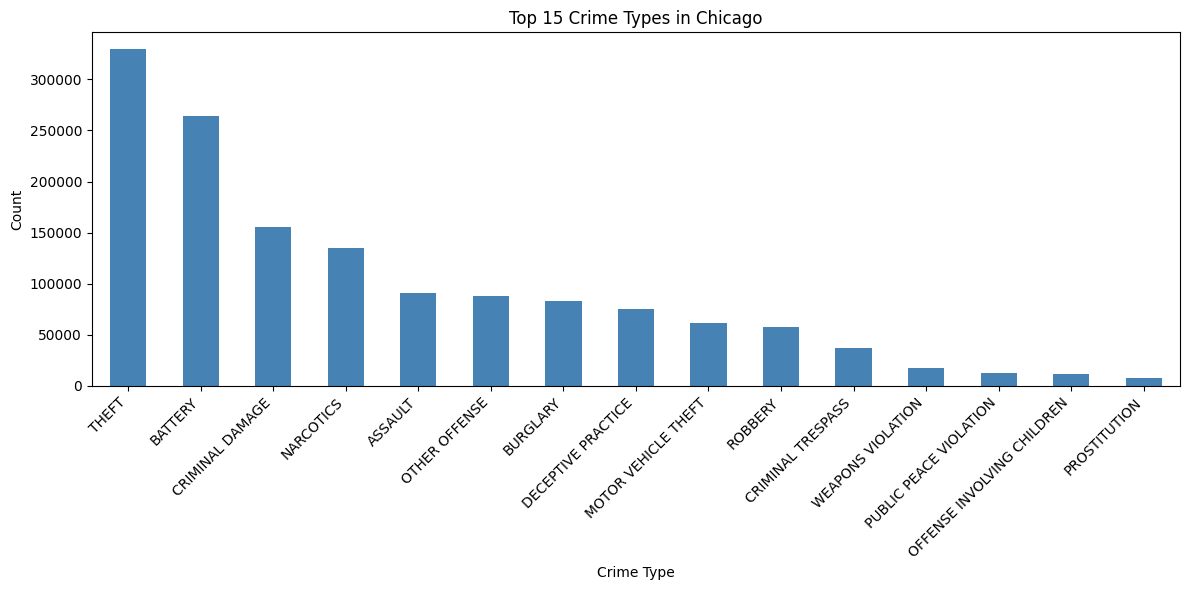

In [9]:
plt.figure(figsize=(12, 6))
df['Primary Type'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Crime Types in Chicago')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

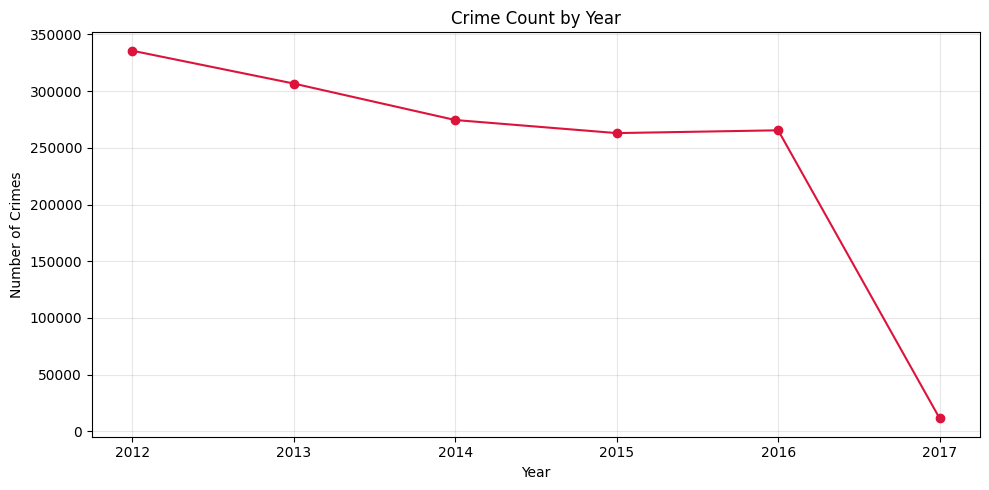

In [13]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

plt.figure(figsize=(10, 5))
df['Year'].value_counts().sort_index().plot(kind='line', marker='o', color='crimson')
plt.title('Crime Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

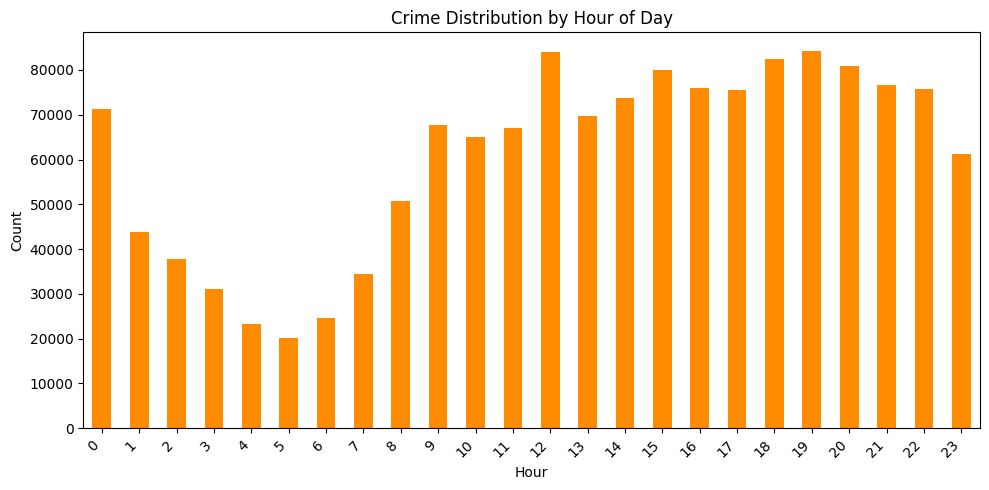

In [15]:
df['Hour'] = df['Date'].dt.hour

plt.figure(figsize=(10, 5))
df['Hour'].value_counts().sort_index().plot(kind='bar', color='darkorange')
plt.title('Crime Distribution by Hour of Day')
plt.xlabel('Hour')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

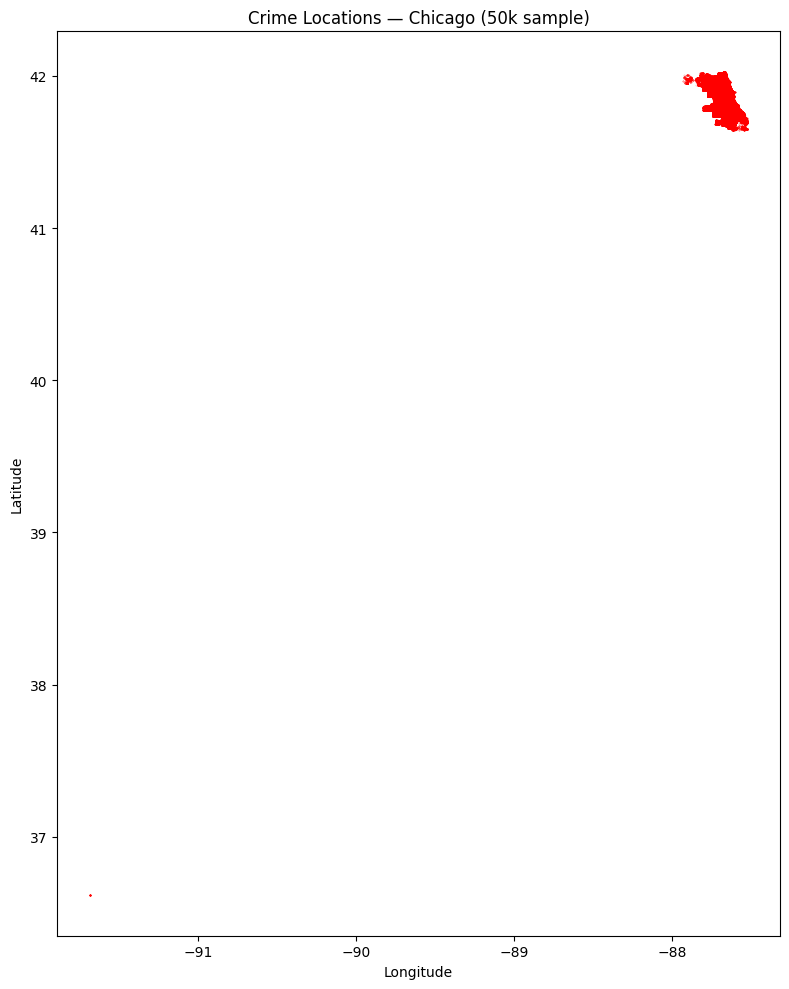

In [17]:
sample = df[['Latitude', 'Longitude']].dropna().sample(500000, random_state=42)

plt.figure(figsize=(8, 10))
plt.scatter(sample['Longitude'], sample['Latitude'], 
            s=0.1, alpha=0.3, color='red')
plt.title('Crime Locations — Chicago (50k sample)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()